In [1]:
import os
import robosuite as suite
from robosuite.wrappers import Wrapper
import robosuite.utils.camera_utils as CU
from robosuite.utils.camera_utils import CameraMover as CM

os.environ["MUJOCO_GL"] = "egl"
size=(64,64)

env =  suite.make(
                "Stack",
                robots="Panda",  # use Sawyer robot
                has_renderer=False,  # on-screen renderer
                has_offscreen_renderer=True,  # off-screen rendering needed for image obs
                use_object_obs=True,  # provide object observations to agent
                use_camera_obs=True,  # provide image observations to agent
                camera_names="agentview",
                camera_depths=True,
                camera_segmentations="element",
                camera_heights= size[0],  # image height
                camera_widths= size[1],  # image width
                horizon=250,  # each episode terminates after 200 steps
                reward_shaping=True,
                control_freq=20,  # control should happen fast enough so that simulation looks smooth
            )

[robosuite WARNING] No private macro file found! (__init__.py:7)
[robosuite WARNING] It is recommended to use a private macro file (__init__.py:8)
[robosuite WARNING] To setup, run: python /home/elephant/miniconda3/envs/urlb/lib/python3.8/site-packages/robosuite-1.4.0-py3.8.egg/robosuite/scripts/setup_macros.py (__init__.py:9)


In [2]:
from collections import OrderedDict

import numpy as np

from robosuite.environments.manipulation.single_arm_env import SingleArmEnv
from robosuite.models.arenas import TableArena
from robosuite.models.objects import BoxObject
from robosuite.models.tasks import ManipulationTask
from robosuite.utils.mjcf_utils import CustomMaterial
from robosuite.utils.observables import Observable, sensor
from robosuite.utils.placement_samplers import UniformRandomSampler
from robosuite.utils.transform_utils import convert_quat


class Test(SingleArmEnv):
    """
    This class corresponds to the lifting task for a single robot arm.
    Args:
        robots (str or list of str): Specification for specific robot arm(s) to be instantiated within this env
            (e.g: "Sawyer" would generate one arm; ["Panda", "Panda", "Sawyer"] would generate three robot arms)
            Note: Must be a single single-arm robot!
        env_configuration (str): Specifies how to position the robots within the environment (default is "default").
            For most single arm environments, this argument has no impact on the robot setup.
        controller_configs (str or list of dict): If set, contains relevant controller parameters for creating a
            custom controller. Else, uses the default controller for this specific task. Should either be single
            dict if same controller is to be used for all robots or else it should be a list of the same length as
            "robots" param
        gripper_types (str or list of str): type of gripper, used to instantiate
            gripper models from gripper factory. Default is "default", which is the default grippers(s) associated
            with the robot(s) the 'robots' specification. None removes the gripper, and any other (valid) model
            overrides the default gripper. Should either be single str if same gripper type is to be used for all
            robots or else it should be a list of the same length as "robots" param
        initialization_noise (dict or list of dict): Dict containing the initialization noise parameters.
            The expected keys and corresponding value types are specified below:
            :`'magnitude'`: The scale factor of uni-variate random noise applied to each of a robot's given initial
                joint positions. Setting this value to `None` or 0.0 results in no noise being applied.
                If "gaussian" type of noise is applied then this magnitude scales the standard deviation applied,
                If "uniform" type of noise is applied then this magnitude sets the bounds of the sampling range
            :`'type'`: Type of noise to apply. Can either specify "gaussian" or "uniform"
            Should either be single dict if same noise value is to be used for all robots or else it should be a
            list of the same length as "robots" param
            :Note: Specifying "default" will automatically use the default noise settings.
                Specifying None will automatically create the required dict with "magnitude" set to 0.0.
        table_full_size (3-tuple): x, y, and z dimensions of the table.
        table_friction (3-tuple): the three mujoco friction parameters for
            the table.
        use_camera_obs (bool): if True, every observation includes rendered image(s)
        use_object_obs (bool): if True, include object (cube) information in
            the observation.
        reward_scale (None or float): Scales the normalized reward function by the amount specified.
            If None, environment reward remains unnormalized
        reward_shaping (bool): if True, use dense rewards.
        placement_initializer (ObjectPositionSampler): if provided, will
            be used to place objects on every reset, else a UniformRandomSampler
            is used by default.
        has_renderer (bool): If true, render the simulation state in
            a viewer instead of headless mode.
        has_offscreen_renderer (bool): True if using off-screen rendering
        render_camera (str): Name of camera to render if `has_renderer` is True. Setting this value to 'None'
            will result in the default angle being applied, which is useful as it can be dragged / panned by
            the user using the mouse
        render_collision_mesh (bool): True if rendering collision meshes in camera. False otherwise.
        render_visual_mesh (bool): True if rendering visual meshes in camera. False otherwise.
        render_gpu_device_id (int): corresponds to the GPU device id to use for offscreen rendering.
            Defaults to -1, in which case the device will be inferred from environment variables
            (GPUS or CUDA_VISIBLE_DEVICES).
        control_freq (float): how many control signals to receive in every second. This sets the amount of
            simulation time that passes between every action input.
        horizon (int): Every episode lasts for exactly @horizon timesteps.
        ignore_done (bool): True if never terminating the environment (ignore @horizon).
        hard_reset (bool): If True, re-loads model, sim, and render object upon a reset call, else,
            only calls sim.reset and resets all robosuite-internal variables
        camera_names (str or list of str): name of camera to be rendered. Should either be single str if
            same name is to be used for all cameras' rendering or else it should be a list of cameras to render.
            :Note: At least one camera must be specified if @use_camera_obs is True.
            :Note: To render all robots' cameras of a certain type (e.g.: "robotview" or "eye_in_hand"), use the
                convention "all-{name}" (e.g.: "all-robotview") to automatically render all camera images from each
                robot's camera list).
        camera_heights (int or list of int): height of camera frame. Should either be single int if
            same height is to be used for all cameras' frames or else it should be a list of the same length as
            "camera names" param.
        camera_widths (int or list of int): width of camera frame. Should either be single int if
            same width is to be used for all cameras' frames or else it should be a list of the same length as
            "camera names" param.
        camera_depths (bool or list of bool): True if rendering RGB-D, and RGB otherwise. Should either be single
            bool if same depth setting is to be used for all cameras or else it should be a list of the same length as
            "camera names" param.
        camera_segmentations (None or str or list of str or list of list of str): Camera segmentation(s) to use
            for each camera. Valid options are:
                `None`: no segmentation sensor used
                `'instance'`: segmentation at the class-instance level
                `'class'`: segmentation at the class level
                `'element'`: segmentation at the per-geom level
            If not None, multiple types of segmentations can be specified. A [list of str / str or None] specifies
            [multiple / a single] segmentation(s) to use for all cameras. A list of list of str specifies per-camera
            segmentation setting(s) to use.
    Raises:
        AssertionError: [Invalid number of robots specified]
    """

    def __init__(
        self,
        robots,
        env_configuration="default",
        controller_configs=None,
        gripper_types="default",
        initialization_noise="default",
        table_full_size=(0.8, 0.8, 0.05),
        table_friction=(1.0, 5e-3, 1e-4),
        use_camera_obs=True,
        use_object_obs=True,
        reward_scale=1.0,
        reward_shaping=False,
        placement_initializer=None,
        has_renderer=False,
        has_offscreen_renderer=True,
        render_camera="frontview",
        render_collision_mesh=False,
        render_visual_mesh=True,
        render_gpu_device_id=-1,
        control_freq=20,
        horizon=1000,
        ignore_done=False,
        hard_reset=True,
        camera_names="agentview",
        camera_heights=256,
        camera_widths=256,
        camera_depths=False,
        camera_segmentations=None,  # {None, instance, class, element}
        renderer="mujoco",
        renderer_config=None,
    ):
        # settings for table top
        self.table_full_size = table_full_size
        self.table_friction = table_friction
        self.table_offset = np.array((0, 0, 0.8))

        # reward configuration
        self.reward_scale = reward_scale
        self.reward_shaping = reward_shaping

        # whether to use ground-truth object states
        self.use_object_obs = use_object_obs

        # object placement initializer
        self.placement_initializer = placement_initializer

        super().__init__(
            robots=robots,
            env_configuration=env_configuration,
            controller_configs=controller_configs,
            mount_types="default",
            gripper_types=gripper_types,
            initialization_noise=initialization_noise,
            use_camera_obs=use_camera_obs,
            has_renderer=has_renderer,
            has_offscreen_renderer=has_offscreen_renderer,
            render_camera=render_camera,
            render_collision_mesh=render_collision_mesh,
            render_visual_mesh=render_visual_mesh,
            render_gpu_device_id=render_gpu_device_id,
            control_freq=control_freq,
            horizon=horizon,
            ignore_done=ignore_done,
            hard_reset=hard_reset,
            camera_names=camera_names,
            camera_heights=camera_heights,
            camera_widths=camera_widths,
            camera_depths=camera_depths,
            camera_segmentations=camera_segmentations,
            renderer=renderer,
            renderer_config=renderer_config,
        )

    def reward(self, action=None):
        """
        Reward function for the task.
        Sparse un-normalized reward:
            - a discrete reward of 2.25 is provided if the cube is lifted
        Un-normalized summed components if using reward shaping:
            - Reaching: in [0, 1], to encourage the arm to reach the cube
            - Grasping: in {0, 0.25}, non-zero if arm is grasping the cube
            - Lifting: in {0, 1}, non-zero if arm has lifted the cube
        The sparse reward only consists of the lifting component.
        Note that the final reward is normalized and scaled by
        reward_scale / 2.25 as well so that the max score is equal to reward_scale
        Args:
            action (np array): [NOT USED]
        Returns:
            float: reward value
        """
        reward = 0.0

        # sparse completion reward
        if self._check_success():
            reward = 2.25

        # use a shaping reward
        elif self.reward_shaping:

            # reaching reward
            cube_pos = self.sim.data.body_xpos[self.cube_body_id]
            gripper_site_pos = self.sim.data.site_xpos[self.robots[0].eef_site_id]
            dist = np.linalg.norm(gripper_site_pos - cube_pos)
            reaching_reward = 1 - np.tanh(10.0 * dist)
            reward += reaching_reward

            # grasping reward
            if self._check_grasp(gripper=self.robots[0].gripper, object_geoms=self.cube):
                reward += 0.25

        # Scale reward if requested
        if self.reward_scale is not None:
            reward *= self.reward_scale / 2.25

        return reward

    def _load_model(self):
        """
        Loads an xml model, puts it in self.model
        """
        super()._load_model()

        # Adjust base pose accordingly
        xpos = self.robots[0].robot_model.base_xpos_offset["table"](self.table_full_size[0])
        self.robots[0].robot_model.set_base_xpos(xpos)

        # load model for table top workspace
        mujoco_arena = TableArena(
            table_full_size=self.table_full_size,
            table_friction=self.table_friction,
            table_offset=self.table_offset,
        )

        # Arena always gets set to zero origin
        mujoco_arena.set_origin([0, 0, 0])

        # initialize objects of interest
        tex_attrib = {
            "type": "cube",
        }
        mat_attrib = {
            "texrepeat": "1 1",
            "specular": "0.4",
            "shininess": "0.1",
        }
        redwood = CustomMaterial(
            texture="WoodRed",
            tex_name="redwood",
            mat_name="redwood_mat",
            tex_attrib=tex_attrib,
            mat_attrib=mat_attrib,
        )
        self.cube = BoxObject(
            name="cube",
            size_min=[0.020, 0.020, 0.020],  # [0.015, 0.015, 0.015],
            size_max=[0.022, 0.022, 0.022],  # [0.018, 0.018, 0.018])
            rgba=[1, 0, 0, 1],
            material=redwood,
        )

        # Create placement initializer
        if self.placement_initializer is not None:
            self.placement_initializer.reset()
            self.placement_initializer.add_objects(self.cube)
        else:
            self.placement_initializer = UniformRandomSampler(
                name="ObjectSampler",
                mujoco_objects=self.cube,
                x_range=[-0.03, 0.03],
                y_range=[-0.03, 0.03],
                rotation=None,
                ensure_object_boundary_in_range=False,
                ensure_valid_placement=True,
                reference_pos=self.table_offset,
                z_offset=0.01,
            )

        # task includes arena, robot, and objects of interest
        self.model = ManipulationTask(
            mujoco_arena=mujoco_arena,
            mujoco_robots=[robot.robot_model for robot in self.robots],
            mujoco_objects=self.cube,
        )

    def _setup_references(self):
        """
        Sets up references to important components. A reference is typically an
        index or a list of indices that point to the corresponding elements
        in a flatten array, which is how MuJoCo stores physical simulation data.
        """
        super()._setup_references()

        # Additional object references from this env
        self.cube_body_id = self.sim.model.body_name2id(self.cube.root_body)

    def _setup_observables(self):
        """
        Sets up observables to be used for this environment. Creates object-based observables if enabled
        Returns:
            OrderedDict: Dictionary mapping observable names to its corresponding Observable object
        """
        observables = super()._setup_observables()

        # low-level object information
        if self.use_object_obs:
            # Get robot prefix and define observables modality
            pf = self.robots[0].robot_model.naming_prefix
            modality = "object"

            # cube-related observables
            @sensor(modality=modality)
            def cube_pos(obs_cache):
                return np.array(self.sim.data.body_xpos[self.cube_body_id])

            @sensor(modality=modality)
            def cube_quat(obs_cache):
                return convert_quat(np.array(self.sim.data.body_xquat[self.cube_body_id]), to="xyzw")

            @sensor(modality=modality)
            def gripper_to_cube_pos(obs_cache):
                return (
                    obs_cache[f"{pf}eef_pos"] - obs_cache["cube_pos"]
                    if f"{pf}eef_pos" in obs_cache and "cube_pos" in obs_cache
                    else np.zeros(3)
                )

            sensors = [cube_pos, cube_quat, gripper_to_cube_pos]
            names = [s.__name__ for s in sensors]

            # Create observables
            for name, s in zip(names, sensors):
                observables[name] = Observable(
                    name=name,
                    sensor=s,
                    sampling_rate=self.control_freq,
                )

        return observables

    def _reset_internal(self):
        """
        Resets simulation internal configurations.
        """
        super()._reset_internal()

        # Reset all object positions using initializer sampler if we're not directly loading from an xml
        if not self.deterministic_reset:

            # Sample from the placement initializer for all objects
            object_placements = self.placement_initializer.sample()

            # Loop through all objects and reset their positions
            for obj_pos, obj_quat, obj in object_placements.values():
                self.sim.data.set_joint_qpos(obj.joints[0], np.concatenate([np.array(obj_pos), np.array(obj_quat)]))

    def visualize(self, vis_settings):
        """
        In addition to super call, visualize gripper site proportional to the distance to the cube.
        Args:
            vis_settings (dict): Visualization keywords mapped to T/F, determining whether that specific
                component should be visualized. Should have "grippers" keyword as well as any other relevant
                options specified.
        """
        # Run superclass method first
        super().visualize(vis_settings=vis_settings)

        # Color the gripper visualization site according to its distance to the cube
        if vis_settings["grippers"]:
            self._visualize_gripper_to_target(gripper=self.robots[0].gripper, target=self.cube)

    def _check_success(self):
        """
        Check if cube has been lifted.
        Returns:
            bool: True if cube has been lifted
        """
        cube_height = self.sim.data.body_xpos[self.cube_body_id][2]
        table_height = self.model.mujoco_arena.table_offset[2]

        # cube is higher than the table top above a margin
        return cube_height > table_height + 0.04

In [4]:
import os
import robosuite as suite
from robosuite.wrappers import Wrapper
import robosuite.utils.camera_utils as CU
from robosuite.utils.camera_utils import CameraMover as CM

os.environ["MUJOCO_GL"] = "egl"
size=(64,64)

env = Test(
                robots="Panda",  # use Sawyer robot
                has_renderer=False,  # on-screen renderer
                has_offscreen_renderer=True,  # off-screen rendering needed for image obs
                use_object_obs=True,  # provide object observations to agent
                use_camera_obs=True,  # provide image observations to agent
                camera_names="agentview",
                camera_depths=True,
                camera_segmentations="element",
                camera_heights= size[0],  # image height
                camera_widths= size[1],  # image width
                horizon=250,  # each episode terminates after 200 steps
                reward_shaping=True,
                control_freq=20,  # control should happen fast enough so that simulation looks smooth
            )

In [5]:
import os, sys

path = os.path.dirname("/srv/sferraro/choreographer/envs.py")
path = os.path.join(path, "custom_robosuite_tasks")


from os.path import dirname, basename, isfile, join
import glob

modules = glob.glob(join(path, "*.py"))
__all__ = [ basename(f)[:-3] for f in modules if isfile(f) and not f.endswith('__init__.py')]

print(__all__)

import importlib
import os

filedir = path
modules = [f[:-3] for f in os.listdir(filedir) if os.path.isfile(os.path.join(filedir, f)) and f.endswith('.py') and f != '__init__.py']
for module_name in modules:
    module = importlib.import_module(f".{module_name}", package=__name__)
    names = [x for x in module.__dict__ if not x.startswith("_")]
    globals().update({name: getattr(module, name) for name in names})

['custom_lift']


ModuleNotFoundError: No module named '__main__.custom_lift'; '__main__' is not a package

In [5]:
from custom_robosuite_tasks.custom_lift import CustomLift

import os
import robosuite as suite
from robosuite.wrappers import Wrapper
import robosuite.utils.camera_utils as CU
from robosuite.utils.camera_utils import CameraMover as CM

# from custom_robosuite_tasks import *

os.environ["MUJOCO_GL"] = "egl"
size=(256,256)

env = CustomLift(
                robots="Panda",  # use Sawyer robot
                has_renderer=False,  # on-screen renderer
                has_offscreen_renderer=True,  # off-screen rendering needed for image obs
                use_object_obs=True,  # provide object observations to agent
                use_camera_obs=True,  # provide image observations to agent
                camera_names="frontview",
                camera_depths=True,
                # render_visual_mesh=False,
                camera_segmentations="element",
                camera_heights= size[0],  # image height
                camera_widths= size[1],  # image width
                horizon=250,  # each episode terminates after 200 steps
                reward_shaping=True,
                control_freq=20,  # control should happen fast enough so that simulation looks smooth
            )

In [2]:
from custom_robosuite_tasks.custom_lift import CustomLift

import os
import robosuite as suite
import robosuite.utils.camera_utils as CU
from robosuite.utils.camera_utils import CameraMover as CM
import custom_robosuite_tasks

class env():
    def __init__(self, task):
        self.task = task
        self.camera = "agentview"
        self.size = (64, 64)
        self.segmentation_level = "element" 
        self.horizon = 250
        self.cube_rgba = (0, 1, 0, 1)
        self.cube_minsize = (0.05, 0.05, 0.05)

    def make(self):
        self._env = custom_robosuite_tasks.make(self.task, self)

        
robot = env("Lift")

robot.make()

# cam_mover = CM(robot._env, camera=robot.camera)
# (
#     start_cam_pos,
#     start_cam_quat,
# ) = cam_mover.get_camera_pose()

# start_cam_pos += [0.2, 0.0, 0.4]

# cam_mover.set_camera_pose(pos=start_cam_pos)

In [6]:
action = [0,0,0,0,0,0,0,0]
env_state, rew, done, info = env.step(action)

def state_extraction(camera, env_state):

        rgb = env_state[camera + "_image"][::-1].transpose(2, 0, 1)
        depth = env_state[camera + "_depth"][::-1].transpose(2, 0, 1)

        # obtain world coordinates from the segmentation mask
        # depth_map = CU.get_real_depth_map(sim=self._env.sim, depth_map=depth)

        seg = env_state[
            camera + "_segmentation_" + "element"
        ][::-1].transpose(2, 0, 1)

        return  rgb, depth, seg

(3, 256, 256)


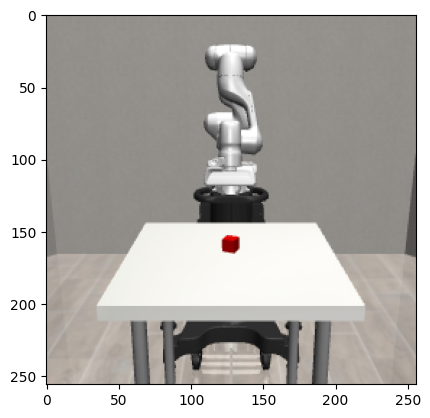

In [7]:
import matplotlib.pyplot as plt

rgb, depth, seg = state_extraction("frontview", env_state)

print(rgb.shape)
plt.imshow(rgb.transpose(1,2,0))

In [29]:
xml = env.model.get_xml

with x as open(xml):
    print(x)


SyntaxError: cannot assign to function call (1523394956.py, line 3)